In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import numpy as np

In [3]:
from pynhd import NLDI
import pydaymet as daymet

Exception ignored on calling ctypes callback function: <function ExecutionEngine._raw_object_cache_notify at 0x7fe2f3aff240>
Traceback (most recent call last):
  File "/home/hkaman/miniconda3/envs/vit/lib/python3.11/site-packages/llvmlite/binding/executionengine.py", line 178, in _raw_object_cache_notify
    def _raw_object_cache_notify(self, data):

KeyboardInterrupt: 


In [4]:
import geopandas as gpd
shapefile_path = '/data2/hkaman/Data/Livingston/shp/Livingston_boundaries.shp'
gdf = gpd.read_file(shapefile_path)
gdf

,OBJECTID,Block_ID,PBLK_N,Property,Shape_STAr,Shape_STLe,Block_Cult,Block_Trel,Plany_Year,SP,RW,Acerage,geometry
0,1286,012,101638.0,LIVINGSTON RANCHES,384474.927206,2785.844387,SYRAH,LIV. DIVIDED CANOPY,1995.0,8.0,10.0,94.96,"POLYGON ((-74318.490 -71836.354, -74279.281 -7..."
1,1290,013,114901.0,LIVINGSTON RANCHES,217547.313819,2074.626132,SYRAH,LIV. DIVIDED CANOPY,1995.0,7.0,12.0,53.36,"POLYGON ((-73627.367 -72269.238, -73632.641 -7..."
2,1292,046,111041.0,LIVINGSTON RANCHES,7369.091935,747.211677,VIOGNIER,LIV. DIVIDED CANOPY,1996.0,5.0,11.0,1.77,"POLYGON ((-69963.887 -71798.421, -69624.519 -7..."
3,1295,022,114380.0,LIVINGSTON RANCHES,152218.597496,1560.626736,PINOT NOIR,SPLIT,1997.0,5.0,10.0,37.46,"POLYGON ((-74226.809 -72994.451, -74036.969 -7..."
4,1297,073,101569.0,LIVINGSTON RANCHES,375442.964282,4288.305871,PINOT NOIR,SPLIT,2003.0,7.0,12.0,94.24,"MULTIPOLYGON (((-69185.270 -71836.061, -69172...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,1735,178,101565.0,LIVINGSTON RANCHES,300865.147889,2542.308577,RIESLING,SPLIT,2012.0,5.0,11.0,73.78,"POLYGON ((-68808.126 -71889.788, -68808.088 -7..."
63,1736,182,101642.0,LIVINGSTON RANCHES,151679.412522,1586.016378,LAMBRUSCO,QUAD,2013.0,5.0,11.0,36.96,"POLYGON ((-70007.949 -71228.358, -69614.932 -7..."
64,1737,009,134736.0,LIVINGSTON RANCHES,609726.284435,3297.303446,PINOT GRIS,STACKED-T,2014.0,4.0,10.0,149.33,"POLYGON ((-75243.772 -74200.375, -75223.806 -7..."
65,1738,021,101662.0,LIVINGSTON RANCHES,847669.773545,8249.993445,PINOT GRIS,STACKED-T,2015.0,4.0,10.0,202.69,"MULTIPOLYGON (((-73059.890 -70346.013, -73049...."


In [5]:
gdf_converted = gdf.to_crs(epsg=4326)
gdf_converted = gdf_converted.sort_values(by='Block_ID', ascending=True)
gdf_converted

,OBJECTID,Block_ID,PBLK_N,Property,Shape_STAr,Shape_STLe,Block_Cult,Block_Trel,Plany_Year,SP,RW,Acerage,geometry
52,1470,003,101650.0,LIVINGSTON RANCHES,579964.925279,6703.774938,MALVASIA BIANCA,4-WIRE VERTICAL W/O,1991.0,7.0,12.0,143.28,"MULTIPOLYGON (((-120.80511 37.37126, -120.8051..."
34,1425,004,101628.0,LIVINGSTON RANCHES,106629.625354,2177.430299,MUSCAT OF ALEXANDRIA,SPLIT,2011.0,5.0,11.0,27.10,"MULTIPOLYGON (((-120.80523 37.36175, -120.8052..."
35,1426,005,101623.0,LIVINGSTON RANCHES,750596.787258,7666.581098,CABERNET SAUVIGNON,LIV. DIVIDED CANOPY,1996.0,5.0,11.0,184.96,"MULTIPOLYGON (((-120.78854 37.36759, -120.7885..."
43,1461,006,101553.0,LIVINGSTON RANCHES,327410.551833,2585.824835,MALVASIA BIANCA,4-WIRE VERTICAL W/O,1993.0,7.0,12.0,80.66,"POLYGON ((-120.82273 37.37160, -120.82236 37.3..."
18,1332,007,101671.0,LIVINGSTON RANCHES,290246.199193,2408.701983,SYMPHONY,LIV. DIVIDED CANOPY,1996.0,5.0,10.0,71.58,"POLYGON ((-120.81726 37.36764, -120.81424 37.3..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,1735,178,101565.0,LIVINGSTON RANCHES,300865.147889,2542.308577,RIESLING,SPLIT,2012.0,5.0,11.0,73.78,"POLYGON ((-120.77804 37.36714, -120.77804 37.3..."
17,1330,181,116409.0,LIVINGSTON RANCHES,71023.546444,1584.047452,SYMPHONY,LIV. DIVIDED CANOPY,1997.0,6.0,10.0,17.47,"MULTIPOLYGON (((-120.79997 37.37478, -120.7986..."
63,1736,182,101642.0,LIVINGSTON RANCHES,151679.412522,1586.016378,LAMBRUSCO,QUAD,2013.0,5.0,11.0,36.96,"POLYGON ((-120.79167 37.37300, -120.78723 37.3..."
15,1319,186,101643.0,LIVINGSTON RANCHES,342326.850544,3710.471747,RIESLING,SPLIT,2012.0,7.0,11.0,84.27,"MULTIPOLYGON (((-120.78702 37.37294, -120.7832..."


In [20]:
geometry = gdf_converted.iloc[5]["geometry"]
geometry.wkt

'MULTIPOLYGON (((-120.83217942629328 37.3697886098877, -120.83211545244498 37.369809075813016, -120.83163776823352 37.36996569267411, -120.83099759479012 37.37021852051031, -120.83059671949341 37.370403233261605, -120.83012878906128 37.37062453501745, -120.8297782019838 37.37078260693113, -120.82947211862 37.370915785092286, -120.82912580401221 37.37107423015061, -120.82868767075045 37.37127943610222, -120.82826060788439 37.37148276964238, -120.82786825854312 37.371660826830336, -120.82739063559441 37.37187240527291, -120.82699866884694 37.37204818446925, -120.82655705175154 37.37224258335787, -120.82608210319901 37.37245730458976, -120.82561659639238 37.37266435312912, -120.82512600753678 37.37288423919815, -120.82467915434755 37.37307907931326, -120.82426125237193 37.37325885762314, -120.82392643494448 37.373425058802034, -120.8238522926588 37.3734545093451, -120.82349063753709 37.37361120503392, -120.82331133778565 37.37368743140572, -120.8232933757404 37.37364074483145, -120.823266

In [6]:
days_2016 = ["2016-04-01", "2016-04-05","2016-04-17","2016-04-26","2016-05-15",
             "2016-05-16","2016-05-21","2016-05-30","2016-06-10","2016-06-15",
             "2016-06-20","2016-06-25","2016-07-01","2016-07-14","2016-07-21",]

days_2017 = ["2017-04-01", "2017-04-20","2017-04-30","2017-05-14","2017-05-20",
             "2017-06-06","2017-06-19","2017-06-26","2017-06-29","2017-07-04",
             "2017-07-09","2017-07-11","2017-07-14","2017-07-16","2017-07-19",]

days_2018 = ["2018-04-01", "2018-04-15","2018-04-22","2018-04-25","2018-05-02",
             "2018-05-12","2018-05-15","2018-05-22","2018-06-01","2018-06-04",
             "2018-06-14","2018-06-24","2018-07-04","2018-07-11","2018-07-14",]

days_2019 = ["2019-04-01", "2019-04-12","2019-04-22","2019-04-25","2019-05-02",
             "2019-05-05","2019-05-12","2019-05-25","2019-06-01","2019-06-04",
             "2019-06-14","2019-06-21","2019-07-01","2019-07-11","2019-07-21",]

In [ ]:
dates = ("2016-03-30", "2016-07-30")
g = gdf_converted[gdf_converted['Block_ID'] == "010"]
geometry = g.iloc[0]["geometry"]
daily = daymet.get_bygeom(geometry, dates, pet="priestley_taylor", snow=True)

In [43]:
def download_met_data(gdf):
    years = [2016, 2017, 2018, 2019]
    var = ["prcp", "tmin", "tmax", "vp"]
    save_dir = "/data2/hkaman/Data/Livingston/weather/"

    for idx, row in gdf.iterrows():
        block_id = row["Block_ID"]
        geometry = row["geometry"]
        
        if block_id not in ["008", "010", "011", "018", "020", "021", "025", "028", "032", 
                            "050", "062", "063", "068", "070", "076", "077", "090", "103", 
                            "105", "107", "125", "172"]:
            for y in years: 

                block_name = os.path.join(save_dir , "LIV_" + str(block_id) + "_" + str(y) + "_met.npy")
                
                if os.path.exists(block_name):
                    #print(f"Already exists!")
                    continue
                else:
                    print(f"============ {block_id}")
                    str_date = str(y) + "-03-30"
                    end_date = str(y) + "-07-30"
                    dates = (str_date, end_date)
                    if y == 2016:
                        days = days_2016
                    elif y == 2017:
                        days = days_2017
                    elif y == 2018:
                        days = days_2018        
                    elif y == 2019:
                        days = days_2019
                    

                    daily = daymet.get_bygeom(geometry, dates, variables=var, pet="priestley_taylor", snow=True)
                    mtx = daily[var].sel(time = days).to_array().to_numpy()

                    np.save(block_name, mtx)
                    print(f"File {block_name} is saved!")
                    


In [ ]:
_ = download_met_data(gdf_converted)

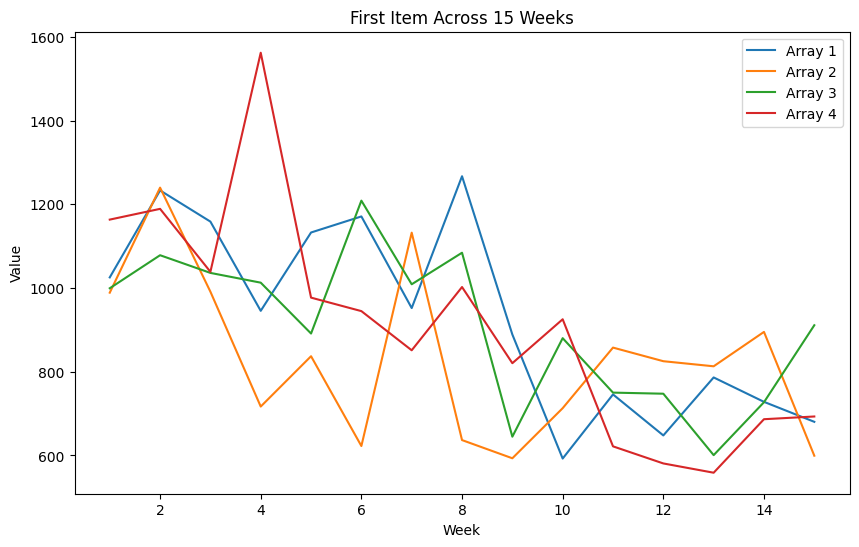

In [47]:
import matplotlib.pyplot as plt

# Load the arrays
array1 = np.load('/data2/hkaman/Data/Livingston/weather/LIV_003_2016_met.npy')
array2 = np.load('/data2/hkaman/Data/Livingston/weather/LIV_003_2017_met.npy')
array3 = np.load('/data2/hkaman/Data/Livingston/weather/LIV_003_2018_met.npy')
array4 = np.load('/data2/hkaman/Data/Livingston/weather/LIV_003_2019_met.npy')

# Prepare the figure and axis for plotting
plt.figure(figsize=(10, 6))

# Extract and plot the first item across 15 weeks for each array
weeks = np.arange(1, 16)  # Assuming weeks 1 to 15
plt.plot(weeks, array1[3, :, 0, 0], label='Array 1')
plt.plot(weeks, array2[3, :, 0, 0], label='Array 2')
plt.plot(weeks, array3[3, :, 0, 0], label='Array 3')
plt.plot(weeks, array4[3, :, 0, 0], label='Array 4')

# Adding plot title and labels
plt.title('First Item Across 15 Weeks')
plt.xlabel('Week')
plt.ylabel('Value')
plt.legend()

# Display the plot
plt.show()

(4, 15, 1, 1)


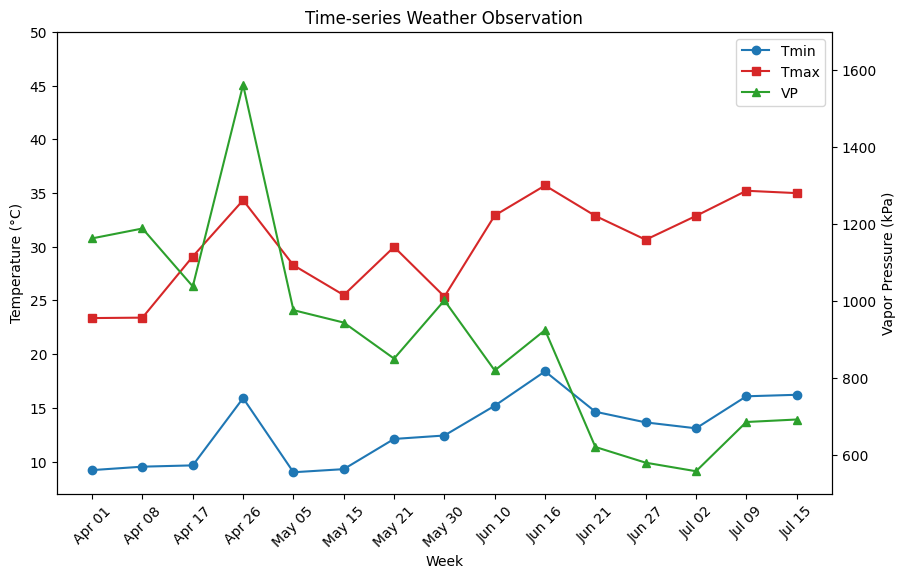

In [24]:
import matplotlib.pyplot as plt

# Load the arrays
B105_2016 = np.load('/data2/hkaman/Data/Livingston/DayMet/LIV_105_2016_met.npy')
B105_2017 = np.load('/data2/hkaman/Data/Livingston/DayMet/LIV_105_2017_met.npy')
B105_2018 = np.load('/data2/hkaman/Data/Livingston/DayMet/LIV_105_2018_met.npy')
B105_2019 = np.load('/data2/hkaman/Data/Livingston/DayMet/LIV_105_2019_met.npy')

print(B105_2019.shape)

Weeks = ['Apr 01', 'Apr 08', 'Apr 17', 'Apr 26', 'May 05', 'May 15', 'May 21', 'May 30', 'Jun 10', 'Jun 16', 'Jun 21', 'Jun 27', 'Jul 02', 'Jul 09', 'Jul 15']
        
fig, ax1 = plt.subplots(figsize=(10, 6))
        
# Plot Tmin and Tmax on the primary y-axis
ax1.plot(Weeks, B105_2019[1, :, 0, 0], label='Tmin', color='tab:blue', marker='o')
ax1.plot(Weeks, B105_2019[2, :, 0, 0], label='Tmax', color='tab:red', marker='s')
ax1.set_xlabel('Week')
ax1.set_ylabel('Temperature (°C)')
ax1.set_ylim(7, 50)
# ax1.tick_params(axis='y', labelcolor='darkgray')
# ax1.legend(loc='upper right')

# Rotate the x-axis labels
plt.xticks(rotation=45)

# Create a secondary y-axis for VP
ax2 = ax1.twinx()
ax2.plot(Weeks, B105_2019[3, :, 0, 0], label='VP', color='tab:green', marker='^')
ax2.set_ylim(500, 1700)
ax2.set_ylabel('Vapor Pressure (kPa)')
# ax2.tick_params(axis='y', labelcolor='darkgray')
# ax2.legend(loc='upper right')


# Collecting all legend handles and labels
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

# Combine legends
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

# Adding plot title
plt.title('Time-series Weather Observation')

# Leave space on top of the canvas
# plt.subplots_adjust(top=0.15)

# Display the plot
plt.show()

In [3]:
# met_dir = "/data2/hkaman/Data/Livingston/weather"
label_dir = "/data2/hkaman/Data/Livingston/data/10m/new_labels"
s1_dir = "/data2/hkaman/Data/Livingston/data/10m/S1_imgs"

In [6]:
label_files = os.listdir(label_dir)
# met_files = os.listdir(met_dir)
s1_files = os.listdir(s1_dir)
print(len(label_files), len(s1_files))

205 205


In [5]:
# Get a list of all files in both directories
label_files = os.listdir(label_dir)
s1_files = os.listdir(s1_dir)

# Loop through the files in the met directory
for s1_file in s1_files:
    # Construct the corresponding label file name
    # Assuming the naming convention is consistent and only the suffix changes from "_met" to "_label"
    corresponding_label_file = s1_file.replace('_img', '_label')
    
    # Check if the corresponding label file exists in the label directory
    if corresponding_label_file not in label_files:
        # If the corresponding label file does not exist, delete or move the met file
        met_file_path = os.path.join(s1_dir, s1_file)
        # To delete the file, uncomment the following line:
        os.remove(met_file_path)
        # Alternatively, to move the file, use os.rename() or shutil.move()
        # For example: shutil.move(met_file_path, 'path/to/new_directory')

        print(f"Processed {s1_file}: corresponding label file does not exist.")

Processed LIV_163_2017_img.npy: corresponding label file does not exist.
Processed LIV_094_2017_img.npy: corresponding label file does not exist.
Processed LIV_064_2017_img.npy: corresponding label file does not exist.
Processed LIV_163_2018_img.npy: corresponding label file does not exist.
Processed LIV_175_2018_img.npy: corresponding label file does not exist.
Processed LIV_175_2019_img.npy: corresponding label file does not exist.
Processed LIV_094_2016_img.npy: corresponding label file does not exist.
Processed LIV_064_2016_img.npy: corresponding label file does not exist.
Processed LIV_094_2018_img.npy: corresponding label file does not exist.
Processed LIV_175_2016_img.npy: corresponding label file does not exist.
Processed LIV_064_2018_img.npy: corresponding label file does not exist.
Processed LIV_094_2019_img.npy: corresponding label file does not exist.
Processed LIV_175_2017_img.npy: corresponding label file does not exist.
Processed LIV_163_2016_img.npy: corresponding label

In [5]:
# Get a list of all files in both directories
label_files = os.listdir(label_dir)
met_files = os.listdir(met_dir)

# Loop through the files in the met directory
for met_file in met_files:
    # Construct the corresponding label file name
    # Assuming the naming convention is consistent and only the suffix changes from "_met" to "_label"
    corresponding_label_file = met_file.replace('_met', '_label')
    
    # Check if the corresponding label file exists in the label directory
    if corresponding_label_file not in label_files:
        # If the corresponding label file does not exist, delete or move the met file
        met_file_path = os.path.join(met_dir, met_file)
        # To delete the file, uncomment the following line:
        os.remove(met_file_path)
        # Alternatively, to move the file, use os.rename() or shutil.move()
        # For example: shutil.move(met_file_path, 'path/to/new_directory')

        print(f"Processed {met_file}: corresponding label file does not exist.")

Processed LIV_027_2018_met.npy: corresponding label file does not exist.
Processed LIV_017_2019_met.npy: corresponding label file does not exist.
Processed LIV_058_2019_met.npy: corresponding label file does not exist.
Processed LIV_022_2019_met.npy: corresponding label file does not exist.
Processed LIV_026_2019_met.npy: corresponding label file does not exist.
Processed LIV_062_2019_met.npy: corresponding label file does not exist.
Processed LIV_015_2016_met.npy: corresponding label file does not exist.
Processed LIV_015_2017_met.npy: corresponding label file does not exist.
Processed LIV_068_2019_met.npy: corresponding label file does not exist.
Processed LIV_015_2018_met.npy: corresponding label file does not exist.
Processed LIV_008_2019_met.npy: corresponding label file does not exist.
Processed LIV_026_2018_met.npy: corresponding label file does not exist.
Processed LIV_021_2016_met.npy: corresponding label file does not exist.
Processed LIV_068_2018_met.npy: corresponding label

In [3]:
import pandas as pd

train = pd.read_csv('/data2/hkaman/Data/Coords/S2/BHO' + '/train.csv', index_col=0) 
train.reset_index(inplace = True, drop = True)

valid = pd.read_csv('/data2/hkaman/Data/Coords/S2/BHO' + '/val.csv', index_col=0)
valid.reset_index(inplace = True, drop = True)

test = pd.read_csv( '/data2/hkaman/Data/Coords/S2/BHO' + '/test.csv', index_col=0)
test.reset_index(inplace = True, drop = True)

In [5]:
train.columns

Index(['block', 'cultivar', 'cultivar_id', 'trellis', 'trellis_id', 'row',
       'space', 'patch_mean', 'year', 'X', 'Y', 'IMG_PATH', 'LABEL_PATH',
       'b_lower_perc', 'b_upper_perc', 'b_minyield', 'b_maxyield',
       'p_lower_perc', 'p_upper_perc', 'p_01gamma', 'p_99gamma', 'p_minyield',
       'p_maxyield', 'p_mingamma', 'p_maxgamma', 'block_mean', 'block_std',
       'win_block_mean', 'win_block_std', 'win_cultivar_mean',
       'win_cultivar_std', 'weight', 'NormWeight', 'MET_PATH', 'TEXT_PATH'],
      dtype='object')

In [6]:
train.head()

,block,cultivar,cultivar_id,trellis,trellis_id,row,space,patch_mean,year,X,...,block_mean,block_std,win_block_mean,win_block_std,win_cultivar_mean,win_cultivar_std,weight,NormWeight,MET_PATH,TEXT_PATH
0,LIV_003_2016,MALVASIA_BIANCA,7,4WIREWO,1,12,7,7.844121,2016,0,...,8.053215,0.607896,8.372056,0.228445,11.190998,2.027858,0.981634,0.000645,/data2/hkaman/Data/Livingston/DayMet/LIV_003_2...,/data2/hkaman/Data/Livingston/text/LIV_003.txt
1,LIV_003_2016,MALVASIA_BIANCA,7,4WIREWO,1,12,7,9.179390,2016,0,...,8.053215,0.607896,8.372056,0.228445,11.190998,2.027858,0.018366,0.000012,/data2/hkaman/Data/Livingston/DayMet/LIV_003_2...,/data2/hkaman/Data/Livingston/text/LIV_003.txt
2,LIV_003_2016,MALVASIA_BIANCA,7,4WIREWO,1,12,7,9.158307,2016,0,...,8.053215,0.607896,8.372056,0.228445,11.190998,2.027858,0.018366,0.000012,/data2/hkaman/Data/Livingston/DayMet/LIV_003_2...,/data2/hkaman/Data/Livingston/text/LIV_003.txt
3,LIV_003_2016,MALVASIA_BIANCA,7,4WIREWO,1,12,7,9.121572,2016,0,...,8.053215,0.607896,8.372056,0.228445,11.190998,2.027858,0.018366,0.000012,/data2/hkaman/Data/Livingston/DayMet/LIV_003_2...,/data2/hkaman/Data/Livingston/text/LIV_003.txt
4,LIV_003_2016,MALVASIA_BIANCA,7,4WIREWO,1,12,7,8.987514,2016,0,...,8.053215,0.607896,8.372056,0.228445,11.190998,2.027858,0.981634,0.000645,/data2/hkaman/Data/Livingston/DayMet/LIV_003_2...,/data2/hkaman/Data/Livingston/text/LIV_003.txt


In [7]:
train.iloc[0]["block"][:7]

'LIV_003'

In [20]:
def add_s1_names(df):
    names = []
    for idx, row in df.iterrows():
        s1_name = os.path.join("/data2/hkaman/Data/Livingston/data/10m/S1_imgs", row["block"] + "_img.npy")
        names.append(s1_name)

    df['S1_PATH'] = names

    return df


In [24]:
train_modified = add_s1_names(train)
train_modified.to_csv('/data2/hkaman/Data/Coords/S2/BHO' + '/train.csv')

valid_modified = add_s1_names(valid)
valid_modified.to_csv('/data2/hkaman/Data/Coords/S2/BHO' + '/val.csv')

test_modified = add_s1_names(test)
test_modified.to_csv('/data2/hkaman/Data/Coords/S2/BHO' + '/test.csv')

In [ ]:
def add_met_names(df):
    names = []
    for idx, row in df.iterrows():
        met_name = os.path.join("/data2/hkaman/Data/Livingston/DayMet", row["block"] + "_met.npy")
        names.append(met_name)

    df['MET_PATH'] = names

    return df

train_modified = add_met_names(train)
train_modified

In [18]:
train_modified = add_met_names(train)
train_modified.to_csv('/data2/hkaman/Data/Coords/S2/BHO' + '/train.csv')

valid_modified = add_met_names(valid)
valid_modified.to_csv('/data2/hkaman/Data/Coords/S2/BHO' + '/val.csv')

test_modified = add_met_names(test)
test_modified.to_csv('/data2/hkaman/Data/Coords/S2/BHO' + '/test.csv')

In [5]:
def add_text_names(df):
    names = []
    for idx, row in df.iterrows():
        text_name = os.path.join("/data2/hkaman/Data/Livingston/text", row["block"][:7] + ".txt")
        names.append(text_name)

    df['TEXT_PATH'] = names

    return df

In [8]:
train_modified = add_text_names(train)
train_modified.to_csv('/data2/hkaman/Data/Coords/S2/BHO' + '/train.csv')

valid_modified = add_text_names(valid)
valid_modified.to_csv('/data2/hkaman/Data/Coords/S2/BHO' + '/val.csv')

test_modified = add_text_names(test)
test_modified.to_csv('/data2/hkaman/Data/Coords/S2/BHO' + '/test.csv')

In [41]:
### Normalizing information:
def met_normalize_info(train):
    tmax_files, tmin_files, vp_files = None, None, None
    for idx, row in train.iterrows():
        met_file = np.load(row['MET_PATH'])

        tmin = met_file[1, :, 0, 0]
        tmin = np.expand_dims(tmin, axis = 0)
        tmin[np.isnan(tmin)] = 0
        if tmin_files is None:
            tmin_files = tmin
        else:
            tmin_files = np.concatenate((tmin_files, tmin), axis = 0)

        tmax = met_file[2, :, 0, 0]
        tmax = np.expand_dims(tmax, axis = 0)
        tmax[np.isnan(tmax)] = 0
        if tmax_files is None:
            tmax_files = tmax
        else:
            tmax_files = np.concatenate((tmax_files, tmax), axis = 0)

        vp = met_file[3, :, 0, 0]
        vp = np.expand_dims(vp, axis = 0)
        vp[np.isnan(vp)] = 0

        if vp_files is None:
            vp_files = vp
        else:
            vp_files = np.concatenate((vp_files, vp), axis = 0)

    # tmin_files = np.concatenate(tmin_files, axis = 0)
    # tmax_files = np.concatenate(tmax_files, axis = 0)
    # vp_files = np.concatenate(vp_files, axis = 0)

    # Initialize dictionaries to hold the mean and std dev for each variable
    stats = {
        'tmin': {'mean': [], 'std': []},
        'tmax': {'mean': [], 'std': []},
        'vp': {'mean': [], 'std': []}
    }

    # Compute mean and std dev for each week and each variable
    for variable, files in zip(['tmin', 'tmax', 'vp'], [tmin_files, tmax_files, vp_files]):
        for week in range(files.shape[1]):  # Iterate over weeks
            week_data = files[:, week]  # Select data for the current week across all files
            stats[variable]['mean'].append(np.mean(week_data))
            stats[variable]['std'].append(np.std(week_data))

    return stats

In [3]:
def met_normalize_info(train):
    tmax_files, tmin_files, vp_files = None, None, None
    for idx, row in train.iterrows():
        met_file = np.load(row['MET_PATH'])

        tmin = met_file[1, :, 0, 0]
        tmin = np.expand_dims(tmin, axis=0)
        tmin[np.isnan(tmin)] = 0
        if tmin_files is None:
            tmin_files = tmin
        else:
            tmin_files = np.concatenate((tmin_files, tmin), axis=0)

        tmax = met_file[2, :, 0, 0]
        tmax = np.expand_dims(tmax, axis=0)
        tmax[np.isnan(tmax)] = 0
        if tmax_files is None:
            tmax_files = tmax
        else:
            tmax_files = np.concatenate((tmax_files, tmax), axis=0)

        vp = met_file[3, :, 0, 0]
        vp = np.expand_dims(vp, axis=0)
        vp[np.isnan(vp)] = 0
        if vp_files is None:
            vp_files = vp
        else:
            vp_files = np.concatenate((vp_files, vp), axis=0)

    # Initialize dictionaries to hold the statistics for each variable
    stats = {
        'tmin': {'mean': [], 'std': [], 'min': [], 'max': []},
        'tmax': {'mean': [], 'std': [], 'min': [], 'max': []},
        'vp': {'mean': [], 'std': [], 'min': [], 'max': []}
    }

    # Compute mean, std dev, min, and max for each week and each variable
    for variable, files in zip(['tmin', 'tmax', 'vp'], [tmin_files, tmax_files, vp_files]):
        for week in range(files.shape[1]):  # Iterate over weeks
            week_data = files[:, week]  # Select data for the current week across all files
            stats[variable]['mean'].append(np.mean(week_data))
            stats[variable]['std'].append(np.std(week_data))
            stats[variable]['min'].append(np.min(week_data))
            stats[variable]['max'].append(np.max(week_data))

    return stats

In [ ]:
stats = met_normalize_info(train)
stats

In [9]:
import json

# Define the file path
file_path = '/data2/hkaman/Data/Coords/met_stats.npz'
np.savez(file_path, stats)

In [63]:
data = np.load('/data2/hkaman/Data/Coords/meteorological_stats.npz', allow_pickle=True)
# Access the dictionary stored in 'arr_0'
stats_dict = data['arr_0'].item()  # Use .item() to get the dictionary from the array

# Now, you can access your data in stats_dict like a normal dictionary
tmin_mean = stats_dict['tmin']['mean']
tmin_std = stats_dict['tmin']['std']
tmax_mean = stats_dict['tmax']['mean']
tmax_std = stats_dict['tmax']['std']
vp_mean = stats_dict['vp']['mean']
vp_std = stats_dict['vp']['std']

In [ ]:
def normalize_met_array(arr):

    for channel in range(1, 4):

        channel_key = {1: 'tmin', 2: 'tmax', 3: 'vp'}[channel]
        mean_values = np.array(stats_dict[channel_key]['mean'])
        std_values = np.array(stats_dict[channel_key]['std'])
        
        for w in range(15):
        arr[channel, :, 0, :] = (arr[channel, :, 0, :] - mean_values.reshape(-1, 1, 1)) / std_values.reshape(-1, 1, 1)

    return arr

In [1]:
text_dir = "/data2/hkaman/Data/Livingston/text"
label_dir = "/data2/hkaman/Data/Livingston/data/10m/new_labels"

In [8]:
# Function to extract unique base names
def extract_unique_names(filenames):
    unique_names = set()
    for filename in filenames:
        # Assuming the base name is always the first two parts (e.g., LIV_003)
        base_name = "_".join(filename.split("_")[:2])
        unique_names.add(base_name)
    return list(unique_names)

# Get the list of unique names
unique_names = extract_unique_names(label_files)
len(unique_names)

56

In [10]:
# Get a list of all files in both directories
label_files = os.listdir(label_dir)
text_files = os.listdir(text_dir)
print(len(label_files), len(text_files))

for text_file in text_files:
    corresponding_label_file = text_file.replace('.txt', '')
    
    # Check if the corresponding label file exists in the label directory
    if corresponding_label_file not in unique_names:
        # If the corresponding label file does not exist, delete or move the met file
        text_file_path = os.path.join(text_dir, text_file)
        # To delete the file, uncomment the following line:
        os.remove(text_file_path)
        # Alternatively, to move the file, use os.rename() or shutil.move()
        # For example: shutil.move(met_file_path, 'path/to/new_directory')

        print(f"Processed {text_file}: corresponding label file does not exist.")

205 61
Processed LIV_126.txt: corresponding label file does not exist.
Processed LIV_175.txt: corresponding label file does not exist.
Processed LIV_015.txt: corresponding label file does not exist.
Processed LIV_163.txt: corresponding label file does not exist.
Processed LIV_094.txt: corresponding label file does not exist.
